In [1]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"
import pandas as pd
import numpy as np
import sys
from copy import deepcopy,copy
from datetime import datetime
import pickle
import sys
import matplotlib.pyplot as plt
import warnings
#warnings.filterwarnings("ignore")
#warnings.filterwarnings("ignore", category=RuntimeWarning)
stderr_fileno = sys.stderr
sys.stderr = open(os.devnull, 'w')

src = os.path.dirname('/export/home/oriolca/Integral_BMS_Governing_Equations/I-BMS/')
sys.path.append(src)
from mcmc_ode import *
from parallel_ode import *

path = os.path.join(src, "Prior/")
sys.path.append(path)
from fit_prior import read_prior_par

priors = {
    "v1_p8": f"Prior/final_prior_param_sq.named_equations.nv1.np8.2017-10-18 18:07:35.261518.dat",
    "v2_p3": f"Prior/final_prior_param_sq.named_equations.nv2.np3.2016-09-09 18:49:42.927679.dat",
    "v2_p4": f"Prior/final_prior_param_sq.named_equations.nv2.np4.2016-09-09 18:49:43.056910.dat",
    "v2_p8": f"Prior/final_prior_param_sq.named_equations.nv2.np8.2016-09-09 18:49:42.800618.dat",
}

data=pd.read_pickle('../Logistic/noise_data/0.01_0.pkl')

print(data)

x = data[['B']]
t = pd.Series(data[['t']].t)

dt = t.to_numpy()[1] - t.to_numpy()[0]

dx = pd.DataFrame(data = {'B': np.gradient(data["B"],t)})

print(x)

print(t)

print(dx)

            B    t
0    0.006303 -6.0
1   -0.020679 -5.9
2    0.007921 -5.8
3   -0.013012 -5.7
4    0.007589 -5.6
..        ...  ...
115  1.012317  5.5
116  1.001676  5.6
117  1.000779  5.7
118  1.004363  5.8
119  0.996912  5.9

[120 rows x 2 columns]
            B
0    0.006303
1   -0.020679
2    0.007921
3   -0.013012
4    0.007589
..        ...
115  1.012317
116  1.001676
117  1.000779
118  1.004363
119  0.996912

[120 rows x 1 columns]
0     -6.0
1     -5.9
2     -5.8
3     -5.7
4     -5.6
      ... 
115    5.5
116    5.6
117    5.7
118    5.8
119    5.9
Name: t, Length: 120, dtype: float64
            B
0   -0.269826
1    0.008087
2    0.038337
3   -0.001659
4    0.150807
..        ...
115  0.013691
116 -0.057689
117  0.013434
118 -0.019339
119 -0.074517

[120 rows x 1 columns]


In [2]:
XLABS = ['B']
n_params = 8

path = os.path.join(src, priors[f"v{len(XLABS)}_p{str(n_params)}"])
prior_par = read_prior_par(path)

Ts=[1] + [1.04**k for k in range(1, 20)]

del prior_par['Nopi_abs']
del prior_par['Nopi2_abs']
del prior_par['Nopi_tan']
del prior_par['Nopi2_tan']
del prior_par['Nopi_sinh']
del prior_par['Nopi2_sinh']
del prior_par['Nopi_cosh']
del prior_par['Nopi2_cosh']
del prior_par['Nopi_tanh']
del prior_par['Nopi2_tanh']


OPS = {
    "sin": 1,
    "cos": 1,
    "exp": 1,
    "pow2": 1,
    "pow3": 1,
    "-": 1,
    "+": 2,
    "*": 2,
    "/": 2,
    "**": 2,
}
import time

start = time.time()
pms_x = Parallel(
    ops=OPS,
    Ts = Ts,
    variables=XLABS,
    parameters=["a%d" % i for i in range(n_params)],
    x=x, t=t, dx=dx,
    prior_par=prior_par,
)
mdl = np.inf
for k in range(4000): # 1k MCMC steps
    pms_x.mcmc_step()
    pms_x.tree_swap()
    if pms_x.t1.E < mdl:
        model_x = deepcopy(pms_x.t1)
        mdl = copy(pms_x.t1.E)

print('PT (T=1) final model',pms_x.t1.E,pms_x.t1)

print(model_x)
print(model_x.E)
print(model_x.par_values)
print(model_x.x0_values)

PT (T=1) final model -355.51150895115256 (((_a7_ * B) + (B ** 2)) * _a7_)
((-(B) + (B ** 2)) * _a7_)
-356.4412443130467
<SharedDict {'d0': {'_a7_': -0.9986677480713522, '_a0_': 1.0, '_a1_': 1.0, '_a2_': 1.0, '_a3_': 1.0, '_a4_': 1.0, '_a5_': 1.0, '_a6_': 1.0}}>
<SharedDict {'d0': array([0.00275344])}>


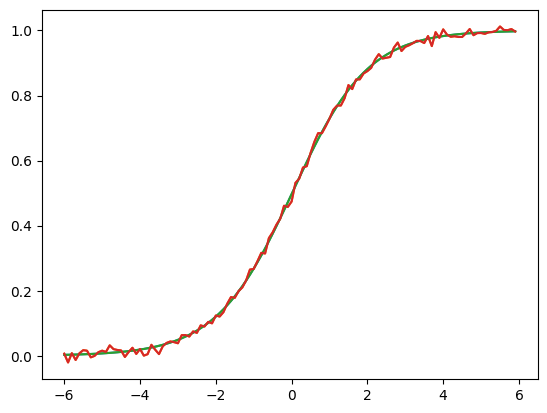

In [3]:
integral = model_x.integrate(t)

plt.plot(t,integral['d0']['B'])
plt.plot(t,x['B'])
plt.plot(t,integral['d0']['B'])
plt.plot(t,x['B'])

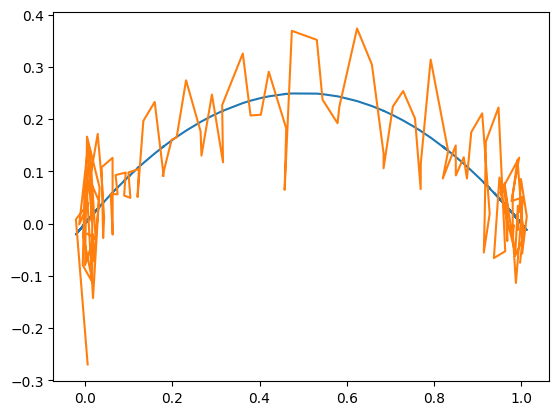

In [6]:
dx_pred = model_x.predict(x)

plt.plot(x['B'],dx_pred['B'])
plt.plot(x['B'],dx['B'])